<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
</head>
<body>
    <div style="display: flex; align-items: center;">
        <div>
            <h1>TD 3 - Signal Detection Theory</h1>
            <h2>Understanding human behavior with cognitive models</h2>
            <h3>Master in Cognitive Science</h3>
            <h4>École Normale Supérieure - PSL</h4>
            <p> Valentin Wyart - Lecturer<br>
                Amric Trudel - Practical Sessions (TD)<br>
                Notebook author: <a href="mailto:amric.trudel@ens.psl.eu">amric.trudel@ens.psl.eu</a></p>
        </div>
        <div>
            <img src="images/logo_ens.png" style="height: 70px; margin-left: 10px;" />
        </div>
    </div>
</body>
</html>

# Objectives
The objective of this TD is to get familiar with model comparison/falsification with the Stimulus Detection Task:
- Implement the High-threshold theory (HTT) model
- Implement the Signal Detection Theory (SDT) model
- Use the Receiver Operating Characteristic (ROC) curve to display the models

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import math
import scipy

# 1- Signal Detection Theory

## Task Description
We will work on a **stimulus detection task**. In such a task, participants are asked to detect the presence of a signal in a series of trials. The signal is embedded in noise, and the participant must decide whether they think the signal is present or not.
- If the signal is present:
    - if the participant detects a signal ("Yes"): **Hit (H)** ✅
    - if the participant doesn't detect it ("No"): **Miss (M)** ❌
- If the signal is NOT present:
    - if the participant detects a signal ("Yes"): **False Alarm (FA)** ❌
    - if the participant doesn't detect it ("No"): **Correct Rejection (CR)** ✅

<img src="images/stimulus_detection_task.png" style="height: 300px; margin-left: 10px;" />

## Data loading
Here we load the data from `data.csv`.
In the dataset, each row corresponds to a trial. Data is collected for two participants, and each participant completed 3 blocks of trials. The stimuli and responses are coded as follows:
- **1** codes for the presence of **signal** in the `stim` column, and for a **'Yes' response** in the `resp` column
- **0** codes for **noise** (without signal) in the `stim` column, and for a **'No' response** in the `resp` column.

In [2]:
data = pd.read_csv('data.csv')
data

,participant,block,stim,resp
0,1,1,0,0
1,1,1,0,0
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1
...,...,...,...,...
5995,2,3,1,0
5996,2,3,0,0
5997,2,3,0,0
5998,2,3,1,1


## Data analysis
To analyze the data, we first classify each trial as a hit (H), misse (M), false alarm (FA), or correct rejection (CR):
<img src="images/contingency_table.png" style="height: 200px; margin-left: 10px;" />

### Contingency statistics
We then compute statistics (rates) for **ONE participant** and **ONE block** at a time.

Read the previous line one more time. 😁

📝 Complete the `contingency_statistics` function, which takes in a DataFrame that contains a `stim` and a `resp` column **of the same participant and same block**, and returns the hit, false-alarm, miss and correct-rejection rates. A 3-step structure is proposed to write this function:
1. Extract the stimuli and responses from the dataframe
2. Count the number of hits, false alarms, misses and correct rejections in the block
3. Compute the four **rates**. For this, you have to normalize the scores so that the sum of each column of the contingency table is equal to 1.

⚠️Be careful! The **number of hits** is NOT the same thing as the **hit rate**!

In [3]:
def contingency_statistics_for_one_block(data_block: pd.DataFrame):
    # Step 1
    stimuli = data_block['stim']
    responses = data_block['resp']

    # Step 2
    hits = (stimuli == 1) & (responses == 1)
    fa = (stimuli == 0) & (responses == 1)
    miss = (stimuli == 1) & (responses == 0)
    cr = (stimuli == 0) & (responses == 0)

    # Step 3
    hit_rate = hits.sum() / (hits.sum() + miss.sum())
    fa_rate = fa.sum() / (fa.sum() + cr.sum())
    miss_rate = miss.sum() / (hits.sum() + miss.sum())
    cr_rate = cr.sum() / (fa.sum() + cr.sum())

    return hit_rate, fa_rate, miss_rate, cr_rate

⚙️ Call your function with the **first block** of the **first participant**.

_Note:_ Pandas DataFrames come with a very handy `query()` method to filter data like in a SQL database.

You should obtain hit_rate=0.61, fa_rate=0.12, miss_rate=0.39, cr_rate=0.88.

In [4]:
hit_rate, fa_rate, miss_rate, cr_rate = contingency_statistics_for_one_block(data.query("participant == 1 and block == 1"))

print(f"Hit rate: {hit_rate:.2f}")
print(f"False alarm rate: {fa_rate:.2f}")
print(f"Miss rate: {miss_rate:.2f}")
print(f"Correct rejection rate: {cr_rate:.2f}")

Hit rate: 0.61
False alarm rate: 0.12
Miss rate: 0.39
Correct rejection rate: 0.88


### Contingency matrix
Hit, miss, false alarm and correction rejection rates are usually visualized in a matrix form.

📝Fill the `plot_contingency_matrix` function to visualize your rates in a contingency matrix like the one shown in the figure above.
Hints:
- You can use the Seaborn library to make a *heatmap*. See [documentation here](https://seaborn.pydata.org/generated/seaborn.heatmap.html).
- Show the rates as decimal numbers in the cells of the matrix (annotations).
- Add a color scale to the side of the matrix.
- Make sure the x and y axes are labeled

_Note:_ Matplotlib and Seaborn can be used together, so you can create your heatmap with Seaborn and use Matplotlib to customize the plot, like adding a title or changing the size.

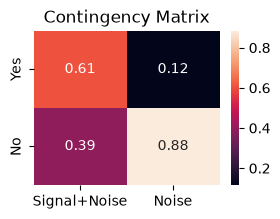

In [5]:
def plot_contingency_matrix(hit_rate, fa_rate, miss_rate, cr_rate):
    matrix = np.array(
        [[hit_rate, fa_rate],    # Fill the matrix in the correct order
         [miss_rate, cr_rate]]
    )
    plt.figure(figsize=(3, 2)) 
    sns.heatmap(matrix, xticklabels=["Signal+Noise","Noise"],yticklabels=["Yes","No"], annot=True)    # Add any arguments you want (see documentation)
    plt.title("Contingency Matrix")
    plt.plot()

# We then call the function
plot_contingency_matrix(hit_rate, fa_rate, miss_rate, cr_rate) # Replace all ... by what seems appropriate

### Plot false alarm rate vs hit rate

📝 In a scatter plot, show the false alarm rate and the hit rate of the block you analyzed:
- Place the false alarm rate (FAR) on the x axis, and the hit rate (HR) on the y axis.
- Set the x and y axis limits to (0, 1)
- Even though we only have one hit rate and one false alarm rate to plot, we will write a function to plot multiple points later.
- Don't call `plt.plot()` at the end of your function, as we will add stuff to your graph later

_Note:_ The method is designed to plot many points, but for now we only have one point to show (block 1 of participant 1).

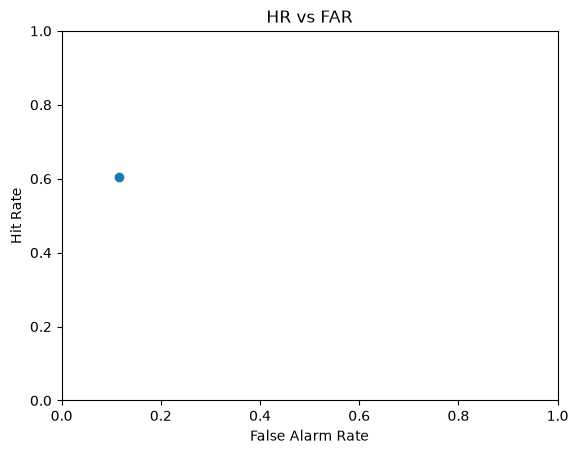

In [6]:
def plot_hr_far(hit_rates: list, fa_rates: list):
    # Your code here
    plt.scatter(fa_rates, hit_rates)
    plt.xlabel('False Alarm Rate')
    plt.ylabel('Hit Rate')
    plt.title('HR vs FAR')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    # Don't call plt.show()


# Here we place the HR and FAR of the first block in lists and call the plotting function
plot_hr_far([hit_rate], [fa_rate])

## Theory #1: High-threshold theory
Now it's time to model the participant's behavior.
Before using the signal detection theory, we will first start with the theory that was popular just before: **high-threshold theory**. This theory characterizes each participant by considering that he/she has a distinct **detection sensitivity**. This means that we assume that a signal $s$ will trigger an (unobserved) sensory response $r(s)$. Then, if the response is higher than the detection sensitivity $p$, the participant will report that they detected a stimulus ("Go"). And if the stimulus response is lower than the sensitivity threshold $p$, we assume that the participant guesses.

In other words:
$$
\begin{align*}
&\text{If } r(s) > p \quad \longrightarrow \quad \textbf{"GO"} \\
&\text{If } r(s) \leq p \quad \longrightarrow \quad \textbf{Guess}
\end{align*}
$$
-------
HTT gives the following formula to estimate $p$ as a function of the hit rate (HR) and the false alarm rate (FAR):
- **Detection sensitivity**: $p = \frac{\text{HR} - \text{FAR}}{1-\text{FAR}}$

The rate at which the participant reports the presence of a sub-threshold stimulus is given by the **detection criterion**, which is equivalent to the false alarm rate (FAR):
- **Detection criterion**: $g = \text{FAR}$

### Compute detection sensitivity and criterion (HTT)
📝 Fill the `compute_htt` function, which computes $p$ and $g$ based on the hit rate and false alarm rate of a participant.

In [7]:
def compute_htt(hit_rate: float, fa_rate: float):
    p = (hit_rate - fa_rate) / (1 - fa_rate) # Fill this
    g = fa_rate # Fill this
    return p, g

p, g = compute_htt(hit_rate, fa_rate) # Fill the arguments

### ROC Curve (HTT)
The purpose of the ROC curve is to visualize the performance of a binary classifier. It is a plot of the hit rate (HR) against the false alarm rate (FAR) for the different possible decision thresholds of the classifier. The ROC curve is a useful tool to compare the performance of different models.

📝 With algebraic manipulations on the HTT equations, find the linear equation that expresses the Hit rate as a function of the False Alarm rate and the detection sensitivity $p$.

$$
\begin{align}
\text{HR}   &= f_p(\text{FAR}) \\
            &= \text{p(1-FAR)+FAR}
\end{align}
$$

📝Fill the `plot_htt_roc_curve` function to display the ROC curve on top of the hr_far scatter plot that you made previously.
- Create a vector of 100 false alarm rate values (`far`) ranging from 0 to 1 (you can use `np.linspace`)
- Calculate the associated hit rates (`hr`) using the equation you just found
- Plot the ROC curve as a line plot of (`hr` vs `far`)
- Add a label and legend to specify the model associated with the ROC curve

⚙️After you have defined the method, the cell will first call `plot_hr_far()`, followed by `plot_htt_roc_curve()` to superimpose both plots on the same figure.

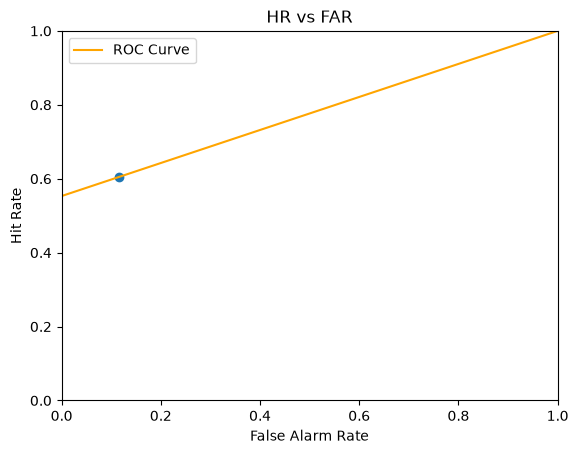

In [8]:
def plot_htt_roc_curve(p):
    # Your code here
    far = np.linspace(0, 1, 100)
    hr = p * (1 - far) + far
    plt.plot(far, hr, label='ROC Curve', color='orange')
    plt.legend()

    # Don't call plt.show()



# We call the function that generates the scatter plot
plot_hr_far([hit_rate], [fa_rate])
# We then call the function that generates the ROC curve (on top of the scatter plot)
plot_htt_roc_curve(p) # Fill the arguments

💭Notice here that the ONLY parameter you need to generate the ROC curve is the sensitivity $p$. How is it that the `plot_htt_roc_curve` function doesn't need the criterion $g$ as well?

Answer this question before moving on.


La courbe est une droite complètement décrite par p

## Theory #2: Signal Detection Theory
Signal Detection Theory has replaced High-Threshold Theory as a reference model for stimulus detection. This theory also defines parameters for detection **sensitivity** and **criterion**.
- **Detection sensitivity**: $d' = z(\text{HR}) - z(\text{FAR})$ 
- **Detection criterion**: $c = - \frac{z(\text{HR}) + z(\text{FAR})}{2}$  
  where $z$ is the z-score function (see [`scipy.stats.norm.ppf`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html))


### Compute detection sensitivity and criterion (SDT)
📝 Fill the `compute_sdt` function, which computes $d'$ and $c$ based on the hit rate and false alarm rate of a participant on a block.

In [9]:
from scipy.stats import norm

def compute_sdt(hit_rate, fa_rate):
    d_prime = norm.ppf(hit_rate) - norm.ppf(fa_rate)  # Fill this
    c = -0.5 * (norm.ppf(hit_rate) + norm.ppf(fa_rate))  # Fill this
    return d_prime, c


d_prime, c = compute_sdt(hit_rate, fa_rate)  # Fill the arguments

### ROC Curve (SDT)
Now we will do the same as we did for the HTT model.

📝 With algebraic manipulations on the SDT equations, find the equation that expresses the Hit rate as a function of the False Alarm rate and the detection sensitivity $d'$.

$$
\begin{align}
\text{HR}   &=  f_{d'}(\text{FAR})  \\
            &=  z(d'+z(FAR))^{-1}
\end{align}
$$

📝 Fill the `plot_sdt_roc_curve` function to display the ROC curve on top of the hr_far scatter plot that you made previously.
- As you did in the previous ROC curve plotting function, generate a vector of 100 HR values and compute the associated FAR values with the equation you just derived.
- You will need to find the inverse of the z-score function, which exists in scipy
- Add a label and legend to specify the model associated with the ROC curve

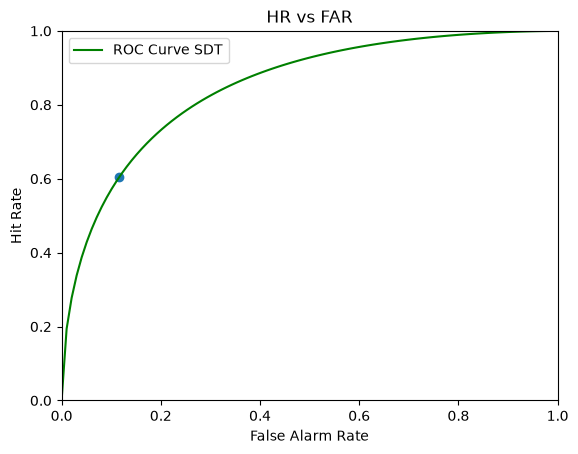

In [10]:
def plot_sdt_roc_curve(d_prime):
    # Your code here
    fa=np.linspace(0, 1, 100)
    hr=norm.cdf(norm.ppf(fa)+d_prime)
    plt.plot(fa,hr, label='ROC Curve SDT', color='green')
    plt.legend()
    # Don't call plt.show()


# Fill the arguments
plot_hr_far([hit_rate], [fa_rate])
plot_sdt_roc_curve(d_prime)

## Model comparison
We generally use ROC curves to compare the models on the same plot.

📝 Plot both ROC Curves (HT and SDT) on the same graph to compare them.
- Generate the scatter plot of the hit rate and false alarm rate
- Add the ROC curve of the HTT model
- Add the ROC curve of the SDT model

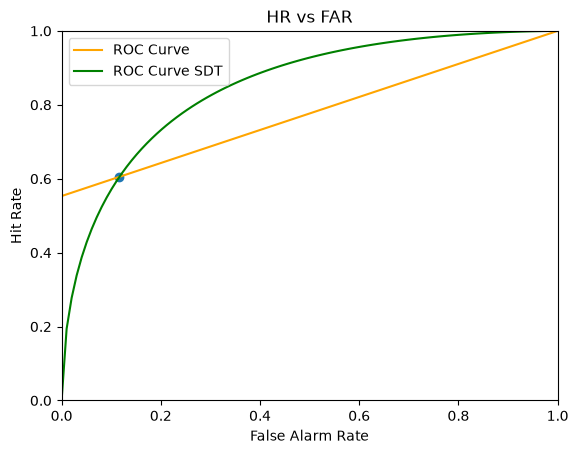

In [11]:
# Your code here (should be 3 lines)
plot_hr_far([hit_rate], [fa_rate])
plot_htt_roc_curve(p)
plot_sdt_roc_curve(d_prime)

💭You have one data point, which corresponds to one block of data on the same task difficulty. If you have implemented the models correctly, both curves should be able to fit that point correctly. How would you describe the difference in the predictions that the two models make, and what additional data would you need to falsify one of the models?

**Write an answer to this question before moving to the next section.**

Il faut d'autres points expérimentaux (faire varier FAR en donnant des instruction à la personne qui fait l'expérience) pour falsifier les modèles. 

## Model falsification
The dataset contains data from 3 different blocks for the first participant. The two alternative models make different predictions about the participant's behavior they change their criterion. Let's see what the actual data looks like on the other blocks that were intended to make the participant more or less conservative by changing the punishment for false alarms.

We can compute the hit rate and the false alarm rates each of the three blocks. We will keep the ROC curves calculated on block 1 and see if its predictions generalize to the other blocks.

📝Create a new plot that allows you to compare the two models on the data from participant 1, and block 1-2-3. Your plot should contain:
- A scatter plot of the hit rates and false alarm rates of **all three blocks**.
- The ROC curve for the HTT model fitted on the data for **block 1 only** (same as you did before)
- The ROC curve for the SDT model fitted on the data for **block 1 only** (same as you did before)

_Hint:_ There are many ways you can achieve this. The cleanest way would be to write a custom function that does all this, but you can also reuse the code from last question and just add the data points from blocks 2 and 3.

In [12]:
def stats_for_all_blocks(data: pd.DataFrame, hit_rate_per_block: list, fa_rate_per_block: list):
    # Your code here
    stats = []
    for block in data['block'].unique():
        block_data = data[data['block'] == block]
        hit_rate, fa_rate, miss_rate, cr_rate = contingency_statistics_for_one_block(block_data)
        hit_rate_per_block.append(hit_rate)
        fa_rate_per_block.append(fa_rate)
        stats.append({
            'block': block,
            'hit_rate': hit_rate,
            'fa_rate': fa_rate,
            'miss_rate': miss_rate,
            'cr_rate': cr_rate,
            'p': p,
            'g': g,
            'd_prime': d_prime,
            'c': c
        })
    return hit_rate_per_block, fa_rate_per_block

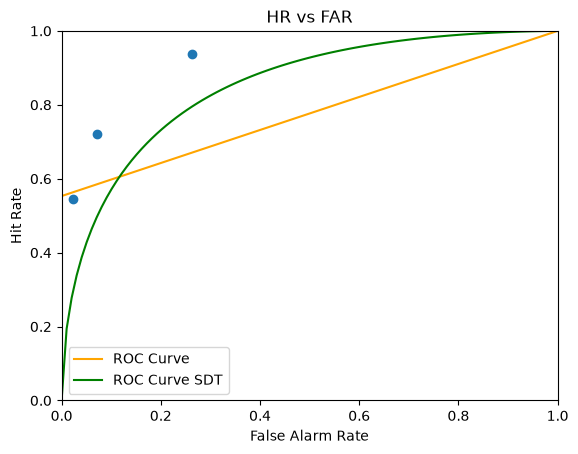

In [13]:
hit_rates_per_block = []
fa_rates_per_block = []
# Compute the hit rates and false alarm rates for each block
hit_rates_per_block, fa_rates_per_block = stats_for_all_blocks(data, hit_rates_per_block, fa_rates_per_block)

# Plot the data points for all blocks
plot_hr_far(hit_rates_per_block, fa_rates_per_block)
# Plot the ROC curves for both models (fitted on the first block)
plot_htt_roc_curve(p)
plot_sdt_roc_curve(d_prime)


💭Can you falsify one of the models with this new data?


We can falsify the ROC htt curve


# Optional exercises
This part is for people who finish the TD early and want to go further.

## 💪 Optional exercise 1: Modelling different subjects
So far we have modelled participant 1. Let's see if we can also model participant 2, who has a **higher sensitivity**.

💭 What do you expect to be different between with this participant?
- How do you expect both ROC curve to look like?
- What parameters will change and how?

📝 On the same graph and for both participants, plot:
- Their HR and FAR for all three blocks
- The ROC curve for the HTT model fitted on the first block
- The ROC corve for the SDT model fitted on the first block

In [ ]:
for _, participant_data in data.groupby('participant'):
    # Fit models on the first block
    ...

    # Plot HR and FAR for all blocks
    ...

    # Plot HTT ROC curve
    ...

    # Plot SDT ROC curve
    ...

## 💪💪💪 Optional exercise 2: Fitting the SDT model on all three blocks at once
So far, we fitted the $d'$ parameter on the first block only and looked if its predictions could generalize to the other blocks. But how would you go about fitting the model to all three blocks?

📝 Focusing on **participant 1**, find a way to fit the SDT model to the data from blocks 1-2-3 simlultaneously and plot your ROC curve to see if it better approaches all three data points instead of only going through the point from block one.  
_Hint:_ Write down all the steps you have to do before you start writing your code. Don't hesitate to discuss it with me. This exercise is intended to be more difficult and less guided.

In [ ]:
# Your code here
